#Kmean Clustering  for Multi-Building Energy Benchmarking

## 1- Data loading

In [5]:
import pandas as pd

# Load saved datasets
df_model = pd.read_csv("clean_data.csv")
df_final = pd.read_csv("processed_data.csv")
df_pca = pd.read_csv("pca_data.csv")
X_reduced = df_pca.values

print("df_pca shape:", df_pca.shape)
print("X_reduced shape:", X_reduced.shape)

df_pca shape: (135735, 9)
X_reduced shape: (135735, 9)


## 2- Find the best number of clusters for Kmeans

## Evaluation metric

##1. Inertia
  Inertia measures how compact the clusters are. It is the total distance between each point and the center of its assigned cluster. Lower inertia is better, but inertia always decreases when K increases. So we do not choose the lowest inertia directly. We look for the elbow point, where improvement starts slowing down.
## 2. Silhouette Score
  Silhouette measures how well-separated and internally consistent the clusters are. It checks whether each point is closer to its own cluster than to other clusters. Range: -1 to 1
  Interpretation:
  Closer to 1 = better separated clusters
  Around 0 = overlapping clusters
  Negative = many points may be in the wrong cluster
## 3. Davies-Bouldin Index
  Davies-Bouldin measures cluster overlap.
  Lower is better. A low value means:clusters are compact and well separated
  A high value means:clusters are overlapping or not clearly separated
## 4. Calinski-Harabasz Score
  Calinski-Harabasz compares separation between clusters against compactness within clusters.Higher is better. A high score means: clusters are far apart and internally compact
  
Silhouette → check separation
Davies-Bouldin → check overlap
Calinski-Harabasz → check compactness vs separation
Interpretability → check if K is useful for benchmarking

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
import pandas as pd
#This code is used to find the best number of  clusters for the Kmeans clustering
k_range = range(2, 11)

results = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = kmeans.fit_predict(X_reduced)

    results.append({
        "K": k,
        "Inertia": kmeans.inertia_,
        "Davies_Bouldin": davies_bouldin_score(X_reduced, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_reduced, labels)
    })

kmeans_k_results_full = pd.DataFrame(results)

display(kmeans_k_results_full)

,K,Inertia,Davies_Bouldin,Calinski_Harabasz
0,2,1.032462e+06,1.044816,33652.561198
1,3,8.662212e+05,1.570482,33079.874553
2,4,7.823069e+05,1.395365,29271.686896
3,5,7.081244e+05,1.385346,27808.216172
4,6,6.438960e+05,1.388071,27173.242298
5,7,5.887039e+05,1.338275,26887.956904
6,8,5.478137e+05,1.308583,26214.176621
7,9,5.145655e+05,1.350155,25515.525571
8,10,4.915849e+05,1.327923,24445.556505


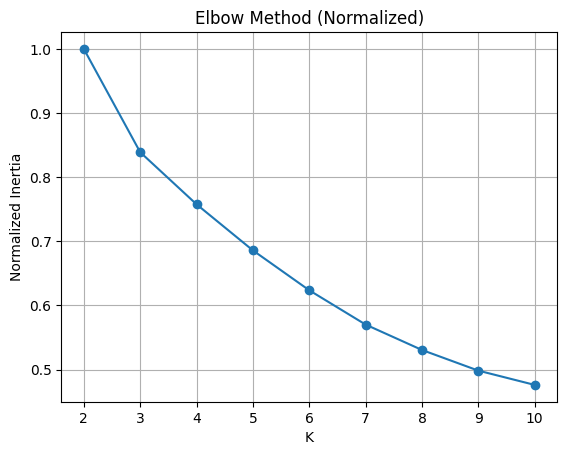

In [8]:
import matplotlib.pyplot as plt
inertia = kmeans_k_results_full["Inertia"]
inertia_norm = inertia / inertia.max()

plt.plot(kmeans_k_results_full["K"], inertia_norm, marker='o')
plt.xlabel("K")
plt.ylabel("Normalized Inertia")
plt.title("Elbow Method (Normalized)")
plt.grid(True)
plt.show()


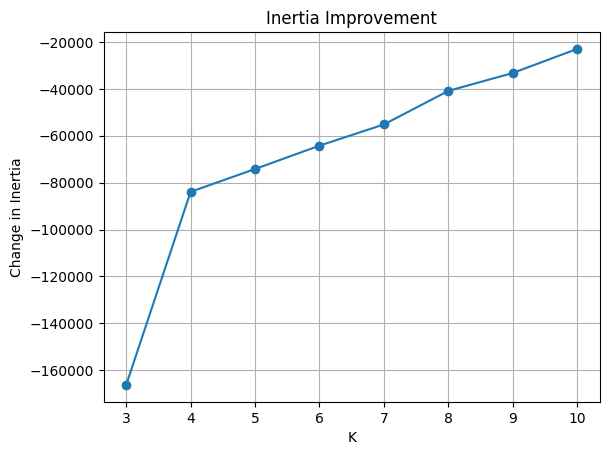

In [9]:
import numpy as np

inertia = kmeans_k_results_full["Inertia"]
diff = np.diff(inertia)

plt.plot(kmeans_k_results_full["K"][1:], diff, marker='o')
plt.xlabel("K")
plt.ylabel("Change in Inertia")
plt.title("Inertia Improvement")
plt.grid(True)
plt.show()

In [ ]:

# SILHOUETTE FOR SELECTED K


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

candidate_k = [2, 3, 4, 5]

sil_results = []

for k in candidate_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = kmeans.fit_predict(X_reduced)

    sil = silhouette_score(X_reduced, labels)

    sil_results.append({
        "K": k,
        "Silhouette": sil
    })

sil_results = pd.DataFrame(sil_results)

display(sil_results)

,K,Silhouette
0,2,0.590853
1,3,0.199064
2,4,0.207294
3,5,0.190810


The number of clusters was selected using inertia (elbow method), Davies–Bouldin, Calinski–Harabasz, and silhouette score.
 K = 2 gave the best Davies–Bouldin and Calinski–Harabasz results, and also the highest silhouette score, showing strong cluster separation.
 However, it produced very broad groups that are not useful for benchmarking.
 The inertia curve showed that the main improvement happened between K = 2 and K = 4, and after that the improvement became small.

K = 3 and K = 4 still had good metric values and created more meaningful groups. For K ≥ 6, the improvement was very small and the clusters became too fragmented.
K = 4 was selected as a balance between good clustering performance and meaningful benchmarking group

## 3- Apply Kmeans clustering method on k=4

In [12]:

# FINAL K-MEANS WITH K=4

from sklearn.cluster import KMeans

K = 4

kmeans_final = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=50
)

kmeans_labels = kmeans_final.fit_predict(X_reduced)

# Attach cluster labels to clean readable data
df_model["cluster_kmeans"] = kmeans_labels

print(df_model["cluster_kmeans"].value_counts().sort_index())

cluster_kmeans
0    73154
1    55528
2     4143
3     2910
Name: count, dtype: int64


#4-K-MEANS t-SNE Visualization
this method is used to visulize high dimentional data
It works by placing similar data points close to each other and dissimilar points far apart.
the visulization at this stage helps to understand how the data is distrbuted between clusters

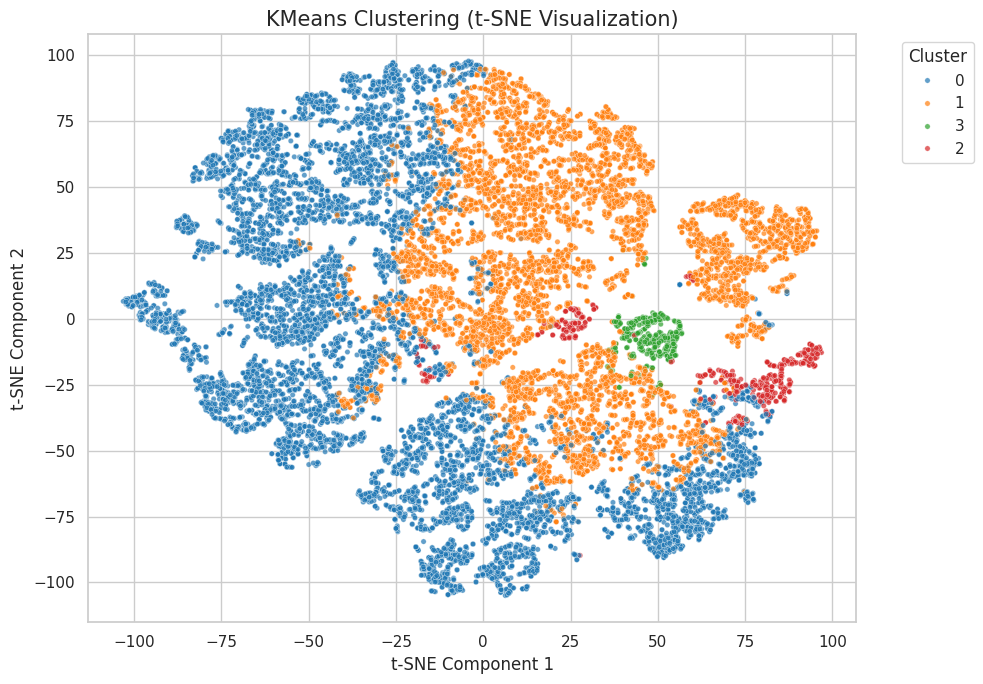

In [11]:

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")


# Data was sampled as the resources are very limited and the runtime crashes when on the full data

plot_sample_size = 20000
np.random.seed(42)

plot_index = np.random.choice(
    X_reduced.shape[0],
    size=min(plot_sample_size, X_reduced.shape[0]),
    replace=False
)

X_plot = X_reduced[plot_index]
labels_plot = kmeans_labels[plot_index]


#  t-SNE function

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_plot)


# Plot

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=labels_plot.astype(str),
    palette="tab10",
    s=15,
    alpha=0.7
)

plt.title("KMeans Clustering (t-SNE Visualization)", fontsize=15)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("kmeans_tsne_visualization.png", dpi=300)
plt.show()

##5- Calculate clustering performance and benchamrk agaist global std

In [22]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Calculate clustering performance
silhouette = silhouette_score(X_reduced, kmeans_labels)
davies_bouldin = davies_bouldin_score(X_reduced, kmeans_labels)
calinski_harabasz = calinski_harabasz_score(X_reduced, kmeans_labels)

print("KMeans Clustering Performance")
print("-----------------------------")
print("Number of clusters:", K)
print("Silhouette Score:", silhouette)
print("Davies-Bouldin Score:", davies_bouldin)
print("Calinski-Harabasz Score:", calinski_harabasz)

KMeans Clustering Performance
-----------------------------
Number of clusters: 4
Silhouette Score: 0.20729426174351526
Davies-Bouldin Score: 1.3953650144471905
Calinski-Harabasz Score: 29271.686896013092


In [17]:
import numpy as np

cluster_sizes = df_model.groupby("cluster_kmeans").size()
cluster_std = df_model.groupby("cluster_kmeans")["site_eui"].std()

cluster_avg_std = np.average(cluster_std, weights=cluster_sizes)

print(cluster_avg_std)

28.910175202141772


In [25]:
global_std = df_model["site_eui"].std()

print(global_std)



51.19636006503824


In [ ]:
df_model.groupby("cluster_kmeans")[[
    "site_eui",
    "ghg_emissions_int",
    "floor_area",
    "energy_star_rating"
]].agg(["mean", "std"])

site_eui             ghg_emissions_int            \
                      mean         std              mean       std   
cluster_kmeans                                                       
0                61.881130   22.758012          4.184132  1.616574   
1               106.699895   30.548518          7.338526  2.510786   
2                94.892595   41.701410          7.130683  2.980417   
3               305.262575  134.094828         23.243568  9.730133   

                  floor_area                energy_star_rating             
                        mean            std               mean        std  
cluster_kmeans                                                             
0               9.443943e+04  104668.422286          71.435670  18.382077  
1               9.235755e+04   99369.690124          28.328987  22.715457  
2               1.167296e+06  577662.058468          58.495776  25.004749  
3               1.649220e+05  278661.318293          38.445017  26.017716

In [ ]:
# Cluster benchmarking statistics
cluster_stats = df_model.groupby("cluster_kmeans")[[
    "site_eui",
    "ghg_emissions_int",
    "floor_area",
    "energy_star_rating"
]].agg(["mean", "std"])

display(cluster_stats)

In [ ]:
# Coefficient of Variation = std / mean
cluster_stats[("site_eui", "cv")] = (
    cluster_stats[("site_eui", "std")] / cluster_stats[("site_eui", "mean")]
)

cluster_stats[("ghg_emissions_int", "cv")] = (
    cluster_stats[("ghg_emissions_int", "std")] / cluster_stats[("ghg_emissions_int", "mean")]
)

display(cluster_stats)

site_eui             ghg_emissions_int            \
                      mean         std              mean       std   
cluster_kmeans                                                       
0                61.881130   22.758012          4.184132  1.616574   
1               106.699895   30.548518          7.338526  2.510786   
2                94.892595   41.701410          7.130683  2.980417   
3               305.262575  134.094828         23.243568  9.730133   

                  floor_area                energy_star_rating             \
                        mean            std               mean        std   
cluster_kmeans                                                              
0               9.443943e+04  104668.422286          71.435670  18.382077   
1               9.235755e+04   99369.690124          28.328987  22.715457   
2               1.167296e+06  577662.058468          58.495776  25.004749   
3               1.649220e+05  278661.318293          38.445017  26.017716   

                site_eui ghg_emissions_int  
                      cv                cv  
cluster_kmeans                              
0               0.367770          0.386358  
1               0.286303          0.342138  
2               0.439459          0.417971  
3               0.439277          0.418616

In [ ]:
pd.crosstab(df_model["cluster_kmeans"], df_model["facility_type"])
#A cross-tabulation was used to examine the distribution of facility types within each cluster

facility_type,Commercial - Other,Commercial - Unknown,Data Center,Education - College or university,Education - Other classroom,Education - Preschool or daycare,Education - Uncategorized,Food Sales,Food Service - Fast food,Food Service - Other,...,Service - Dry-cleaning or Laundry,Service - Other service,Service - Post office or postal center,Service - Vehicle service/repair shop,Single Family - Uncategorized,Transportation Terminal,Warehouse - Distribution or Shipping center,Warehouse - Non-refrigerated,Warehouse - Refrigerated,Warehouse - Self-storage
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,
0,280,4,14,513,3105,872,28,13,1,3,...,1,41,5,310,1,30,501,1774,132,936
1,390,0,44,326,1198,116,13,36,0,4,...,0,25,0,361,4,6,125,414,52,38
2,26,0,8,138,18,0,0,0,0,0,...,0,0,0,8,0,0,13,2,0,0
3,86,0,298,43,22,3,0,13,0,0,...,0,5,0,105,0,12,12,35,4,0


# the next plots are to understand the bnechmarks better and hwo data are destirbuted between the clusters

In [ ]:
cluster_summary = df_model.groupby("cluster_kmeans")[[
    "site_eui",
    "ghg_emissions_int",
    "energy_star_rating"
]].mean().round(2)

display(cluster_summary)

,site_eui,ghg_emissions_int,energy_star_rating
cluster_kmeans,,,
0,61.88,4.18,71.44
1,106.70,7.34,28.33
2,94.89,7.13,58.50
3,305.26,23.24,38.45


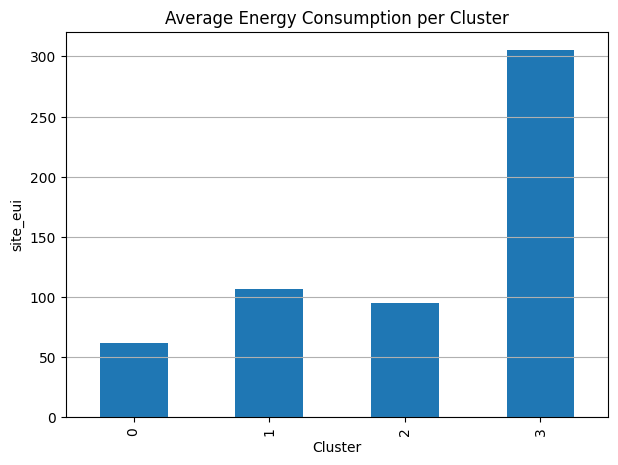

In [ ]:
import matplotlib.pyplot as plt

cluster_summary["site_eui"].plot(kind="bar", figsize=(7,5))
plt.title("Average Energy Consumption per Cluster")
plt.ylabel("site_eui")
plt.xlabel("Cluster")
plt.grid(axis="y")
plt.show()

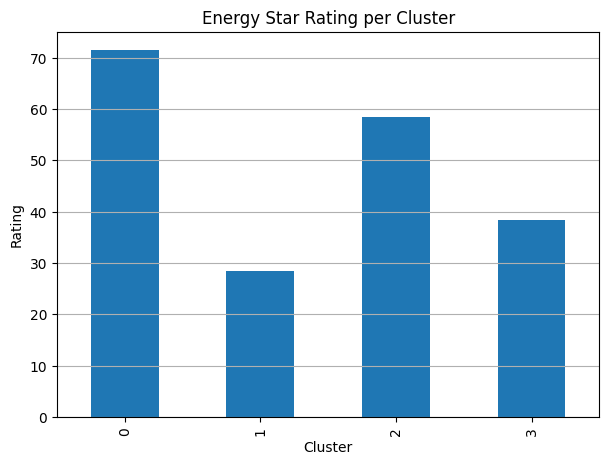

In [ ]:
cluster_summary["energy_star_rating"].plot(kind="bar", figsize=(7,5))
plt.title("Energy Star Rating per Cluster")
plt.ylabel("Rating")
plt.xlabel("Cluster")
plt.grid(axis="y")
plt.show()

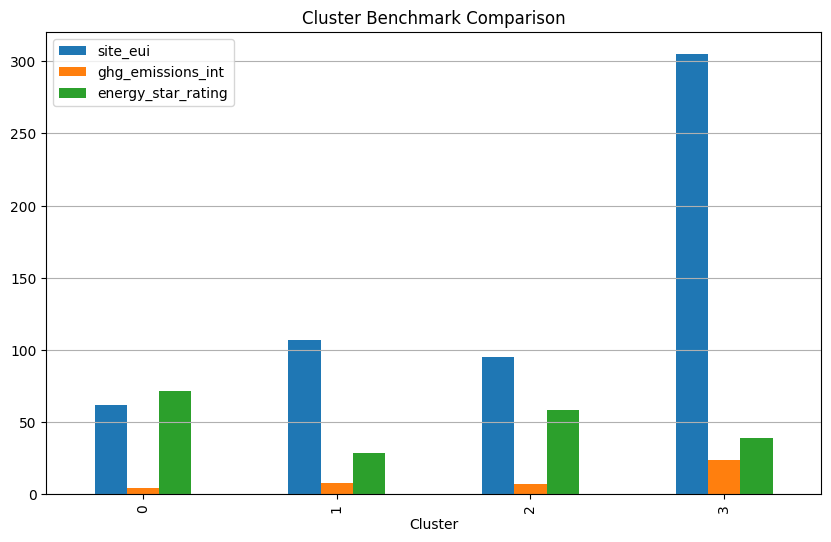

In [ ]:
cluster_summary.plot(kind="bar", figsize=(10,6))
plt.title("Cluster Benchmark Comparison")
plt.xlabel("Cluster")
plt.grid(axis="y")
plt.show()

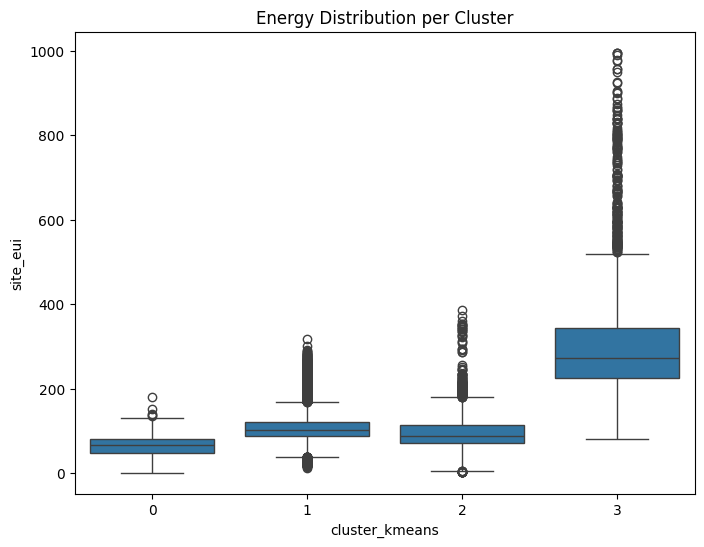

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x="cluster_kmeans", y="site_eui", data=df_model)
plt.title("Energy Distribution per Cluster")
plt.show()

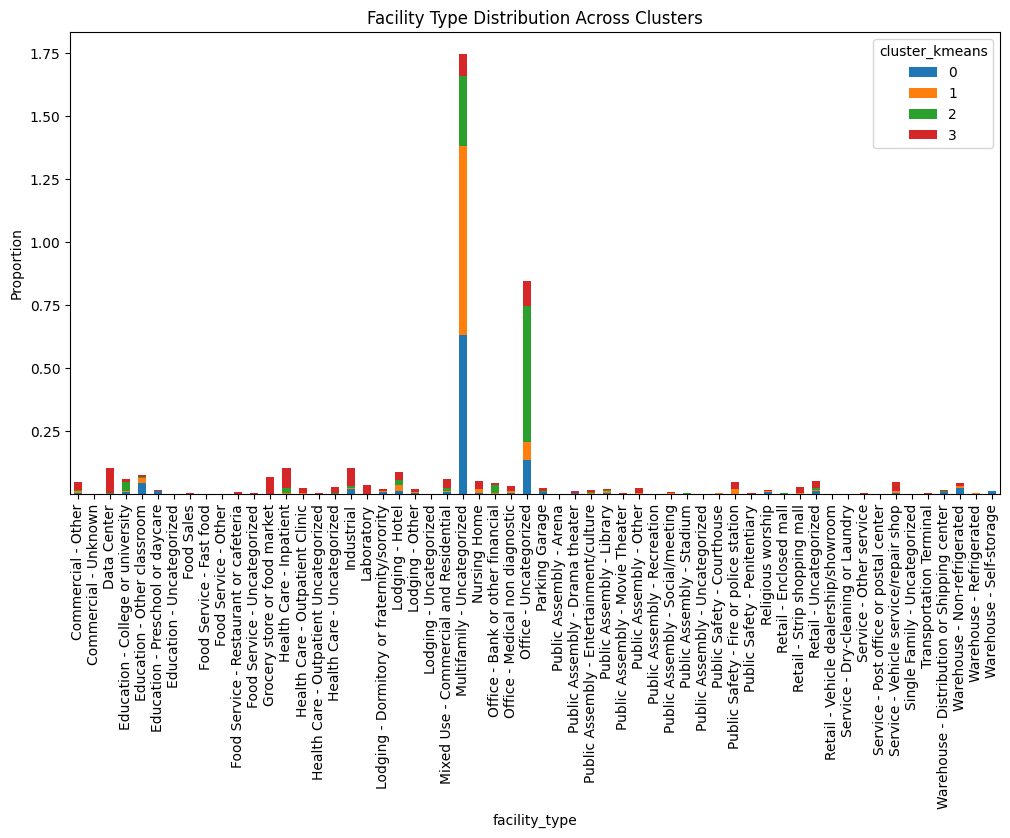

In [ ]:
ct = pd.crosstab(df_model["cluster_kmeans"], df_model["facility_type"], normalize="index")

ct.T.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Facility Type Distribution Across Clusters")
plt.ylabel("Proportion")
plt.show()

# Addtional: testing kmeans without sklearn
## This experiment is only for understanding how K-Means works -just for learning

In [28]:
# =========================
# EXPERIMENT: K-MEANS STEP BY STEP
# This is only to understand how K-Means works internally
# The original data will not be changed
# =========================

import numpy as np

# Make copies for the experiment
X_exp = np.asarray(X_reduced).copy()
df_exp = df_model.copy()

K_exp = 4
random_state_exp = 42
max_iter_exp = 300
tolerance_exp = 0.0001

np.random.seed(random_state_exp)

# Randomly choose initial centroids
initial_indices_exp = np.random.choice(X_exp.shape[0], K_exp, replace=False)
centroids_exp = X_exp[initial_indices_exp]

for iteration_exp in range(max_iter_exp):

    # Calculate distances
    distances_exp = np.linalg.norm(X_exp[:, np.newaxis] - centroids_exp, axis=2)

    # Assign each point to nearest centroid
    labels_exp = np.argmin(distances_exp, axis=1)

    # Update centroids
    new_centroids_exp = []

    for k in range(K_exp):
        if np.any(labels_exp == k):
            new_centroids_exp.append(X_exp[labels_exp == k].mean(axis=0))
        else:
            new_centroids_exp.append(centroids_exp[k])

    new_centroids_exp = np.array(new_centroids_exp)

    # Stop when centroids stop moving much
    shift_exp = np.linalg.norm(new_centroids_exp - centroids_exp)

    centroids_exp = new_centroids_exp

    if shift_exp < tolerance_exp:
        break

# Add labels only to the copied dataframe
df_exp["cluster_kmeans_step"] = labels_exp

print("===== EXPERIMENT COPY: K-MEANS STEP BY STEP =====")
print("Iterations:", iteration_exp + 1)
print(df_exp["cluster_kmeans_step"].value_counts().sort_index())

===== EXPERIMENT COPY: K-MEANS STEP BY STEP =====
Iterations: 40
cluster_kmeans_step
0     2974
1    44176
2    32729
3    55856
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score



print("===== CLUSTERING PERFORMANCE =====")
print("Number of clusters:", K_exp)
print("Silhouette Score:", silhouette_score(X_exp, labels_exp))
print("Davies-Bouldin Score:", davies_bouldin_score(X_exp, labels_exp))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_exp, labels_exp))



cluster_summary_exp = df_exp.groupby("cluster_kmeans_step")[[
    "site_eui",
    "ghg_emissions_int"
]].agg(["mean", "std"])

site_cv_exp = cluster_summary_exp["site_eui"]["std"] / cluster_summary_exp["site_eui"]["mean"]
ghg_cv_exp = cluster_summary_exp["ghg_emissions_int"]["std"] / cluster_summary_exp["ghg_emissions_int"]["mean"]

print("\n===== BENCHMARKING QUALITY =====")
print("Average CV for site_eui:", site_cv_exp.mean())
print("Average CV for ghg_emissions:", ghg_cv_exp.mean())
print("Best Avg Cluster CV:", ((site_cv_exp + ghg_cv_exp) / 2).min())
print("Best Single CV:", min(site_cv_exp.min(), ghg_cv_exp.min()))



global_std_site_exp = df_exp["site_eui"].std()
global_std_ghg_exp = df_exp["ghg_emissions_int"].std()

cluster_avg_std_site_exp = cluster_summary_exp["site_eui"]["std"].mean()
cluster_avg_std_ghg_exp = cluster_summary_exp["ghg_emissions_int"]["std"].mean()

improvement_site_exp = ((global_std_site_exp - cluster_avg_std_site_exp) / global_std_site_exp) * 100
improvement_ghg_exp = ((global_std_ghg_exp - cluster_avg_std_ghg_exp) / global_std_ghg_exp) * 100

print("\n===== BENCHMARKING IMPROVEMENT =====")
print("Global Std (site_eui):", global_std_site_exp)
print("Cluster Avg Std (site_eui):", cluster_avg_std_site_exp)
print("Improvement site_eui (%):", improvement_site_exp)

print("\nGlobal Std (ghg_emissions):", global_std_ghg_exp)
print("Cluster Avg Std (ghg_emissions):", cluster_avg_std_ghg_exp)
print("Improvement ghg_emissions (%):", improvement_ghg_exp)